<a href="https://colab.research.google.com/github/mamun-career-tech/Cervical_Cancer_Prediction_ML_and_DL/blob/main/Cervical_Cancer_Voting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Section

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

from imblearn.over_sampling import SMOTE

## Dataset Read

In [ ]:
Cervical_Cancer_Data = pd.read_csv('/content/risk_factors_cervical_cancer.csv')
#Cervical_Cancer_Data

for name in Cervical_Cancer_Data.columns:
  mean = np.array(Cervical_Cancer_Data[f'{name}'] != "?").mean()
  Cervical_Cancer_Data[name] = Cervical_Cancer_Data[name].replace({"?": mean})

In [ ]:
#Cervical_Cancer_Data.Number_of_sexual_partners.unique()

In [ ]:
#Cervical_Cancer_Data.Num_of_pregnancies.unique()

In [ ]:
#Cervical_Cancer_Data.Dx_HPV.unique()

In [ ]:
#Cervical_Cancer_Data.isnull().sum()

In [ ]:
#Cervical_Cancer_Data.isnull().sum().sum()

In [ ]:
#Cervical_Cancer_Data_mean = Cervical_Cancer_Data.mean()
#Cervical_Cancer_Data = Cervical_Cancer_Data.fillna(Cervical_Cancer_Data_mean)

#Cervical_Cancer_Data = Cervical_Cancer_Data.fillna('Unknown')

In [ ]:
#Cervical_Cancer_Data.isnull().sum().sum()

In [ ]:
#Cervical_Cancer_Data.isnull().sum()

In [ ]:
pd.options.mode.chained_assignment = None

## Label Encode

In [ ]:
le = LabelEncoder()

In [ ]:
#Cervical_Cancer_Data.dtypes

In [ ]:
Cervical_Cancer_Data.Age = le.fit_transform(Cervical_Cancer_Data['Age'])
Cervical_Cancer_Data.Number_of_sexual_partners = le.fit_transform(Cervical_Cancer_Data['Number_of_sexual_partners'])
Cervical_Cancer_Data.First_sexual_intercourse = le.fit_transform(Cervical_Cancer_Data['First_sexual_intercourse'])
Cervical_Cancer_Data.Num_of_pregnancies = le.fit_transform(Cervical_Cancer_Data['Num_of_pregnancies'])
Cervical_Cancer_Data.Smokes = le.fit_transform(Cervical_Cancer_Data['Smokes'])
Cervical_Cancer_Data.Smokes_years = le.fit_transform(Cervical_Cancer_Data['Smokes_years'])
Cervical_Cancer_Data.Smokes_packs_per_year = le.fit_transform(Cervical_Cancer_Data['Smokes_packs_per_year'])
Cervical_Cancer_Data.Hormonal_Contraceptives = le.fit_transform(Cervical_Cancer_Data['Hormonal_Contraceptives'])
Cervical_Cancer_Data.Hormonal_Contraceptives_years = le.fit_transform(Cervical_Cancer_Data['Hormonal_Contraceptives_years'])
Cervical_Cancer_Data.IUD = le.fit_transform(Cervical_Cancer_Data['IUD'])
Cervical_Cancer_Data.IUD_years = le.fit_transform(Cervical_Cancer_Data['IUD_years'])
Cervical_Cancer_Data.STDs = le.fit_transform(Cervical_Cancer_Data['STDs'])
Cervical_Cancer_Data.STDs_number = le.fit_transform(Cervical_Cancer_Data['STDs_number'])
Cervical_Cancer_Data.STDs_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_condylomatosis'])
Cervical_Cancer_Data.STDs_cervical_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_cervical_condylomatosis'])
Cervical_Cancer_Data.STDs_vaginal_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_vaginal_condylomatosis'])
Cervical_Cancer_Data.STDs_vulvo_perineal_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_vulvo_perineal_condylomatosis'])
Cervical_Cancer_Data.STDs_syphilis = le.fit_transform(Cervical_Cancer_Data['STDs_syphilis'])
Cervical_Cancer_Data.STDs_pelvic_inflammatory_disease = le.fit_transform(Cervical_Cancer_Data['STDs_pelvic_inflammatory_disease'])
Cervical_Cancer_Data.STDs_genital_herpes = le.fit_transform(Cervical_Cancer_Data['STDs_genital_herpes'])
Cervical_Cancer_Data.STDs_molluscum_contagiosum = le.fit_transform(Cervical_Cancer_Data['STDs_molluscum_contagiosum'])
Cervical_Cancer_Data.STDs_AIDS = le.fit_transform(Cervical_Cancer_Data['STDs_AIDS'])
Cervical_Cancer_Data.STDs_HIV = le.fit_transform(Cervical_Cancer_Data['STDs_HIV'])
Cervical_Cancer_Data.STDs_Hepatitis_B = le.fit_transform(Cervical_Cancer_Data['STDs_Hepatitis_B'])
Cervical_Cancer_Data.STDs_HPV = le.fit_transform(Cervical_Cancer_Data['STDs_HPV'])
Cervical_Cancer_Data.STDs_Number_of_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Number_of_diagnosis'])
Cervical_Cancer_Data.STDs_Time_since_first_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Time_since_first_diagnosis'])
Cervical_Cancer_Data.STDs_Time_since_last_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Time_since_last_diagnosis'])
Cervical_Cancer_Data.Dx_Cancer = le.fit_transform(Cervical_Cancer_Data['Dx_Cancer'])
Cervical_Cancer_Data.Dx_CIN = le.fit_transform(Cervical_Cancer_Data['Dx_CIN'])
Cervical_Cancer_Data.Dx_HPV = le.fit_transform(Cervical_Cancer_Data['Dx_HPV'])
Cervical_Cancer_Data.Dx = le.fit_transform(Cervical_Cancer_Data['Dx'])
Cervical_Cancer_Data.Hinselmann = le.fit_transform(Cervical_Cancer_Data['Hinselmann'])
Cervical_Cancer_Data.Schiller = le.fit_transform(Cervical_Cancer_Data['Schiller'])
Cervical_Cancer_Data.Citology = le.fit_transform(Cervical_Cancer_Data['Citology'])
Cervical_Cancer_Data.Biopsy = le.fit_transform(Cervical_Cancer_Data['Biopsy'])

In [ ]:
#Cervical_Cancer_Data.dtypes

In [ ]:
#Cervical_Cancer_Data.Biopsy.value_counts()

## Drop result feature from dataset

In [ ]:
x = Cervical_Cancer_Data.drop(['Biopsy'], axis = 1)
y = Cervical_Cancer_Data['Biopsy']
#x.shape

## Mutual Information

In [ ]:
mutual_info = mutual_info_classif(x,y)
mutual_info = pd.Series(mutual_info)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

Schiller                              0.141717
Hinselmann                            0.062383
Citology                              0.046732
STDs_number                           0.020087
Dx_HPV                                0.018179
Dx                                    0.014126
STDs_Number_of_diagnosis              0.013454
Hormonal_Contraceptives_years         0.012812
Dx_CIN                                0.012311
IUD_years                             0.011063
Age                                   0.008096
STDs_molluscum_contagiosum            0.008011
STDs_syphilis                         0.007978
STDs_cervical_condylomatosis          0.006289
STDs                                  0.006050
Hormonal_Contraceptives               0.006032
Dx_Cancer                             0.005145
STDs_vulvo_perineal_condylomatosis    0.005083
IUD                                   0.004207
STDs_condylomatosis                   0.003872
Number_of_sexual_partners             0.003821
STDs_Hepatiti

In [ ]:
#Cervical_Cancer_Data.STDs_AIDS.describe()

# Figure for Dataset Features

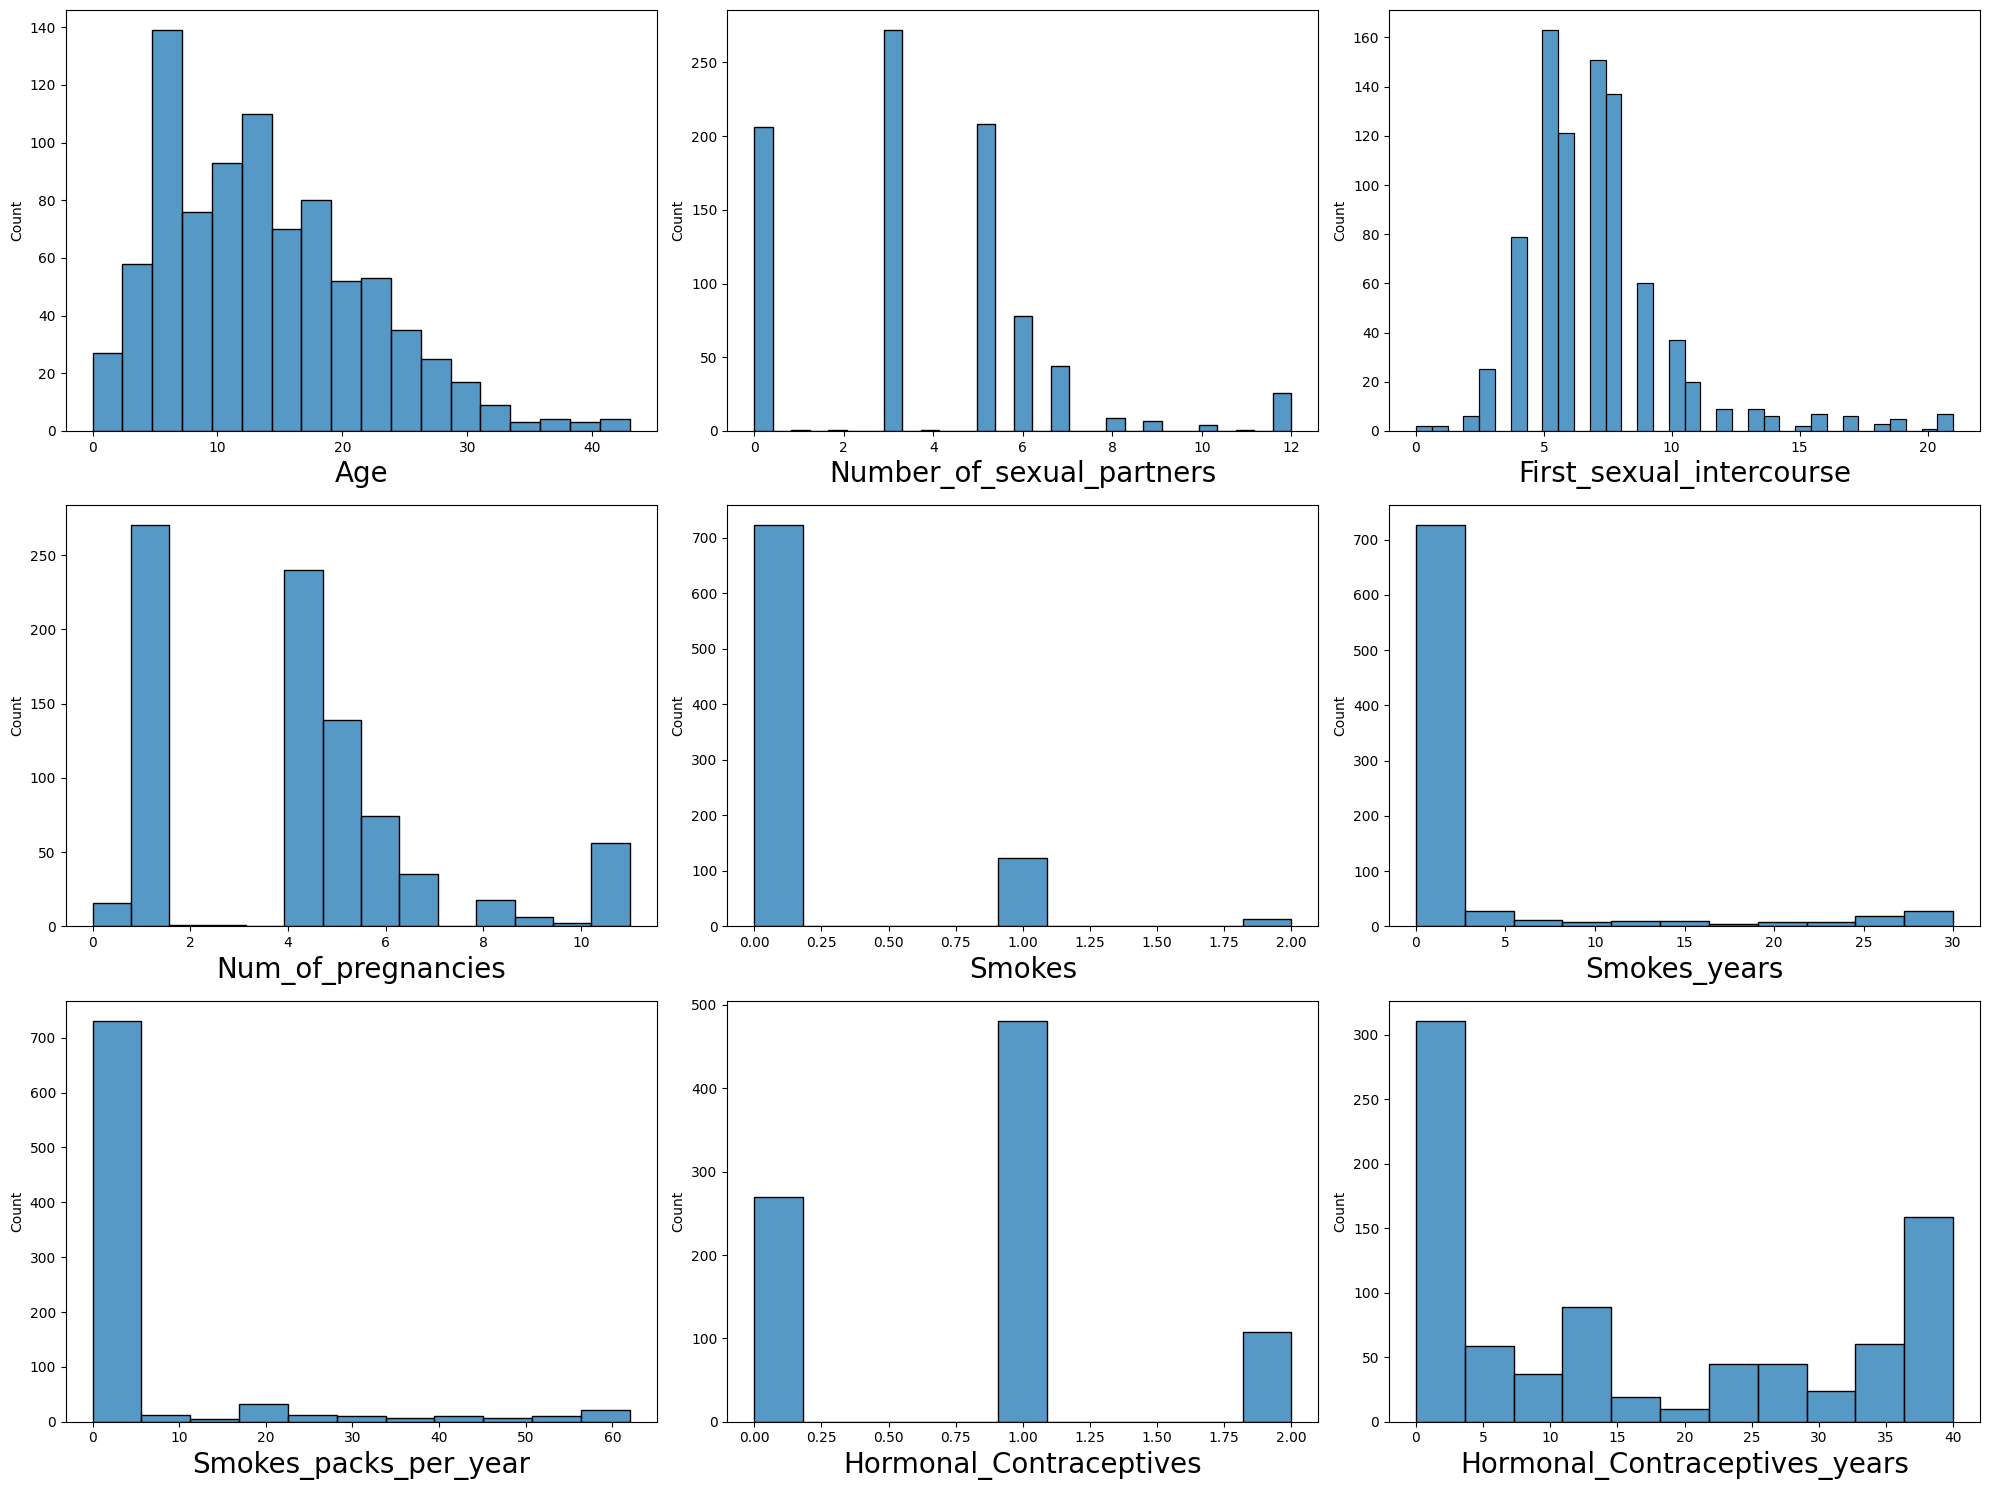

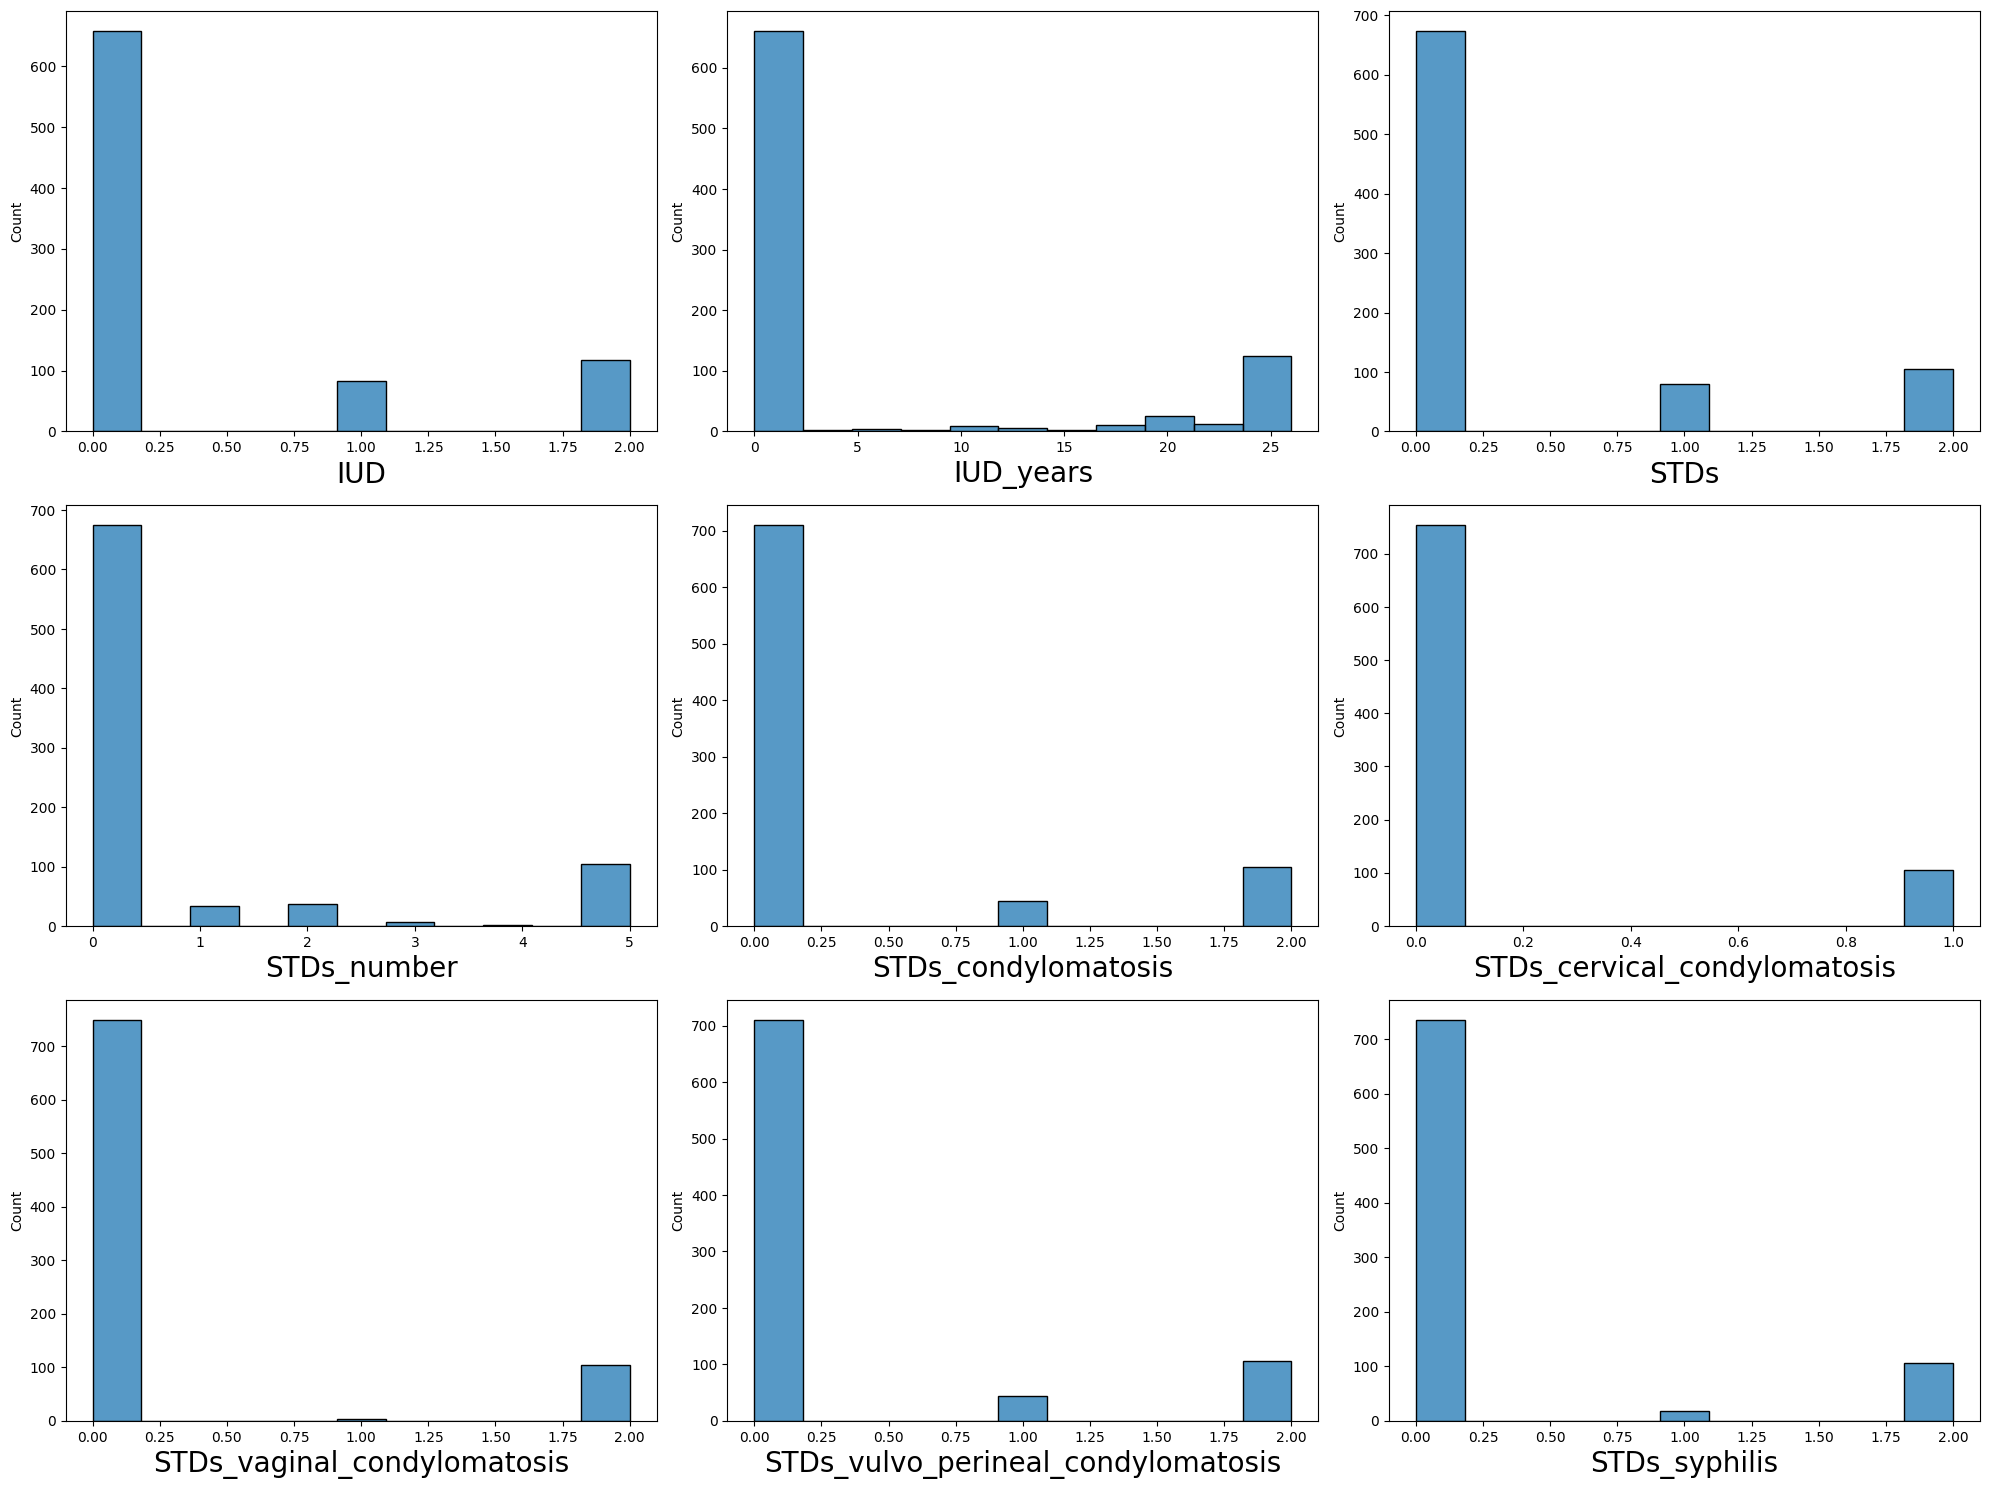

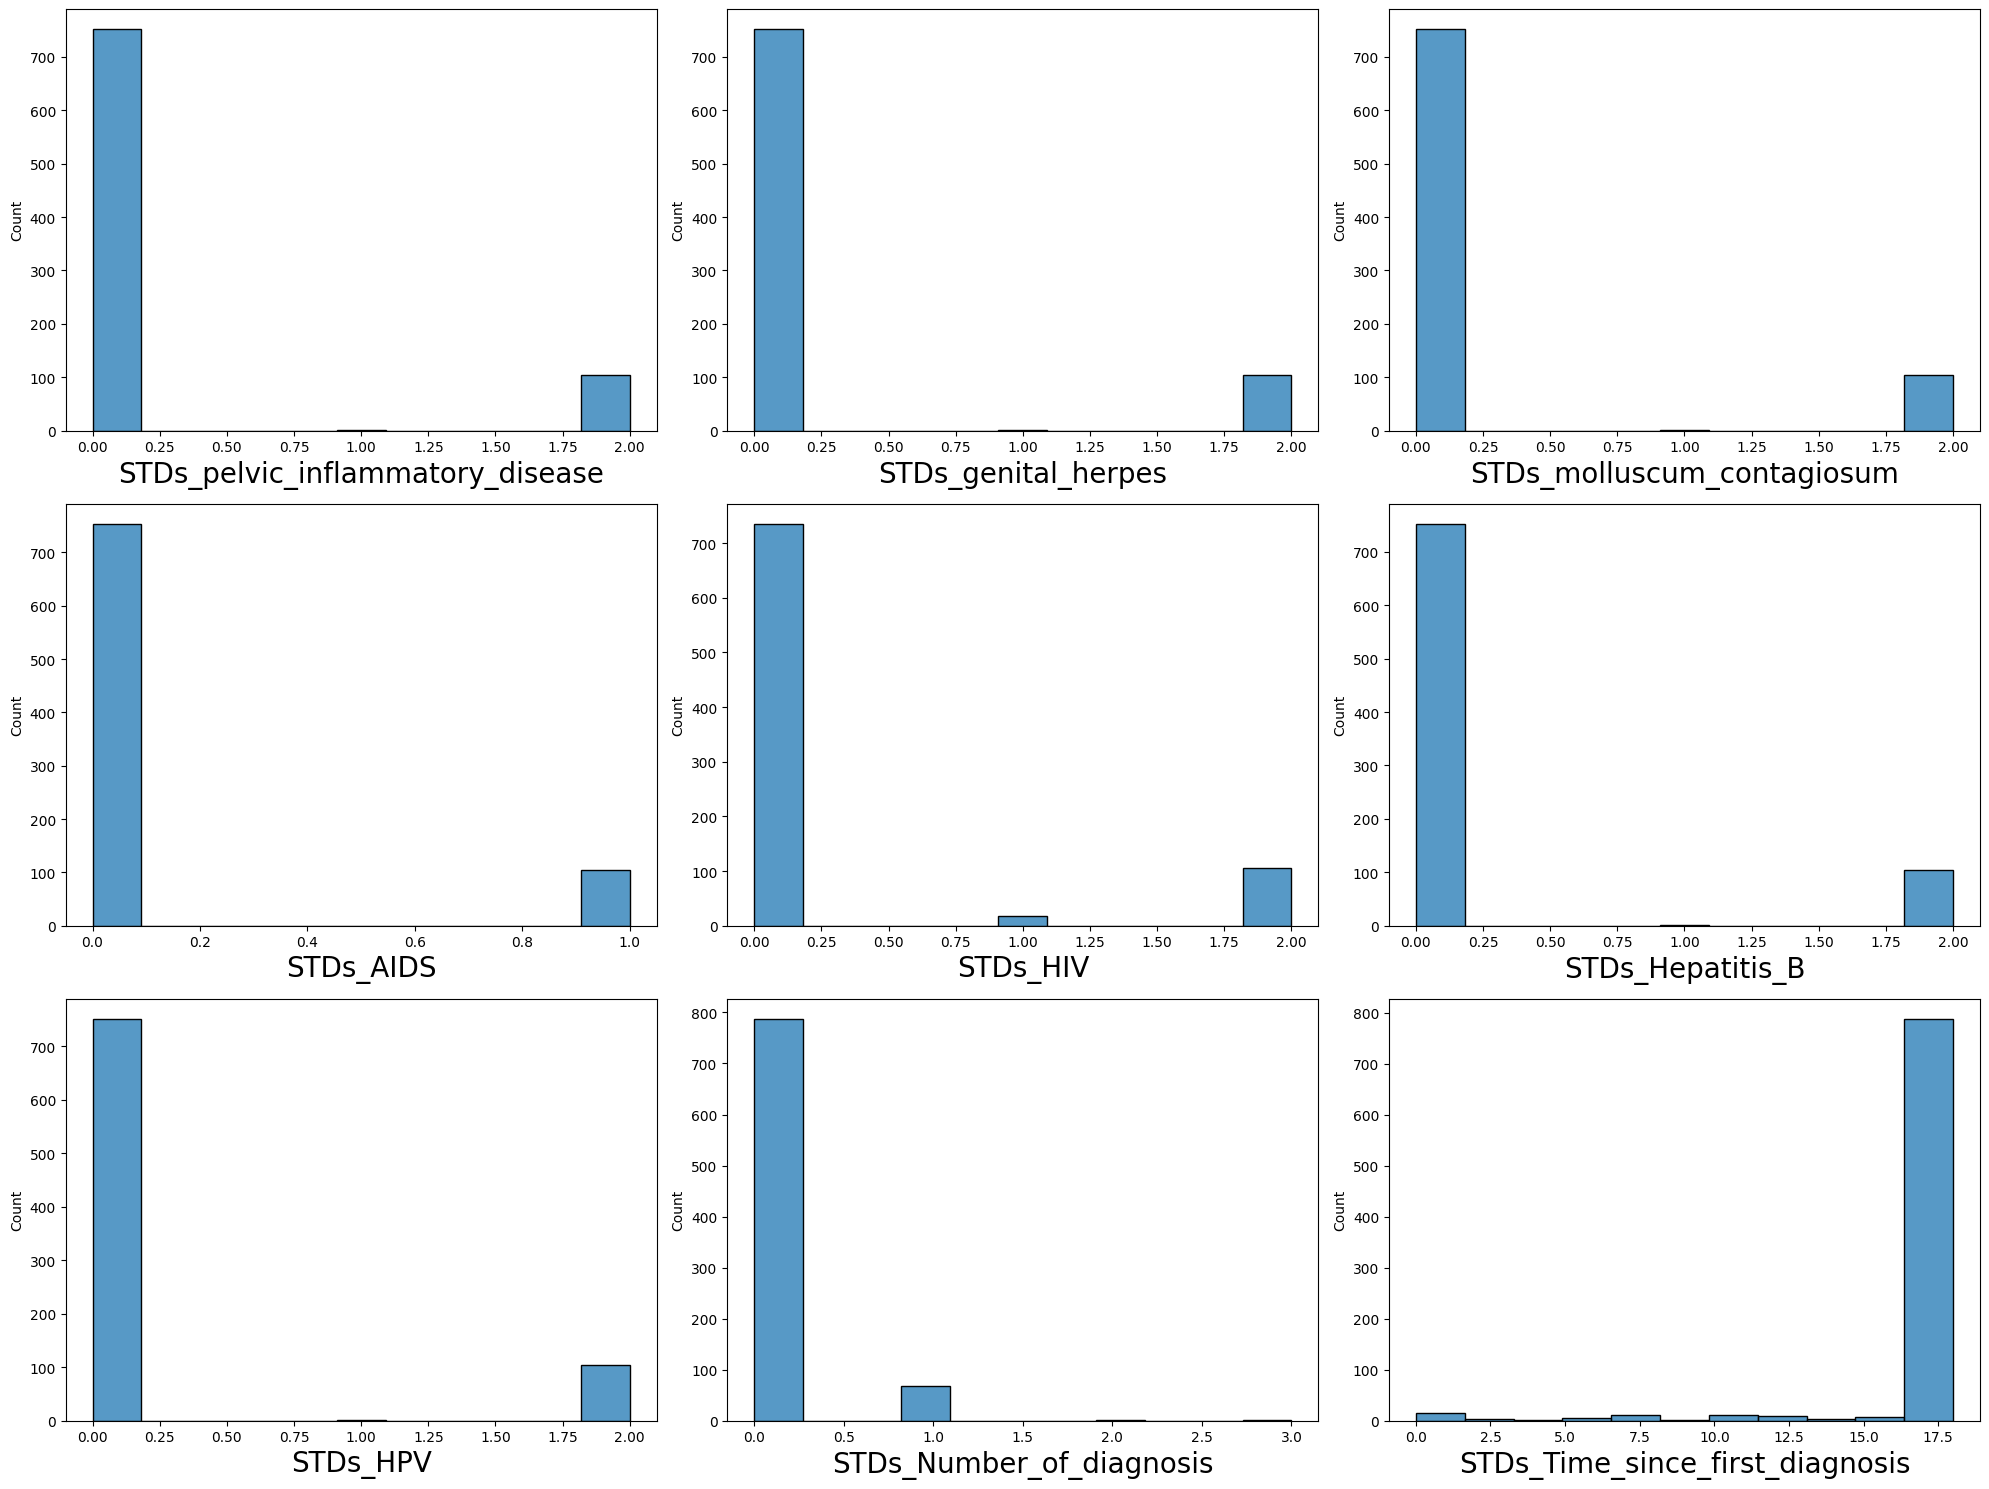

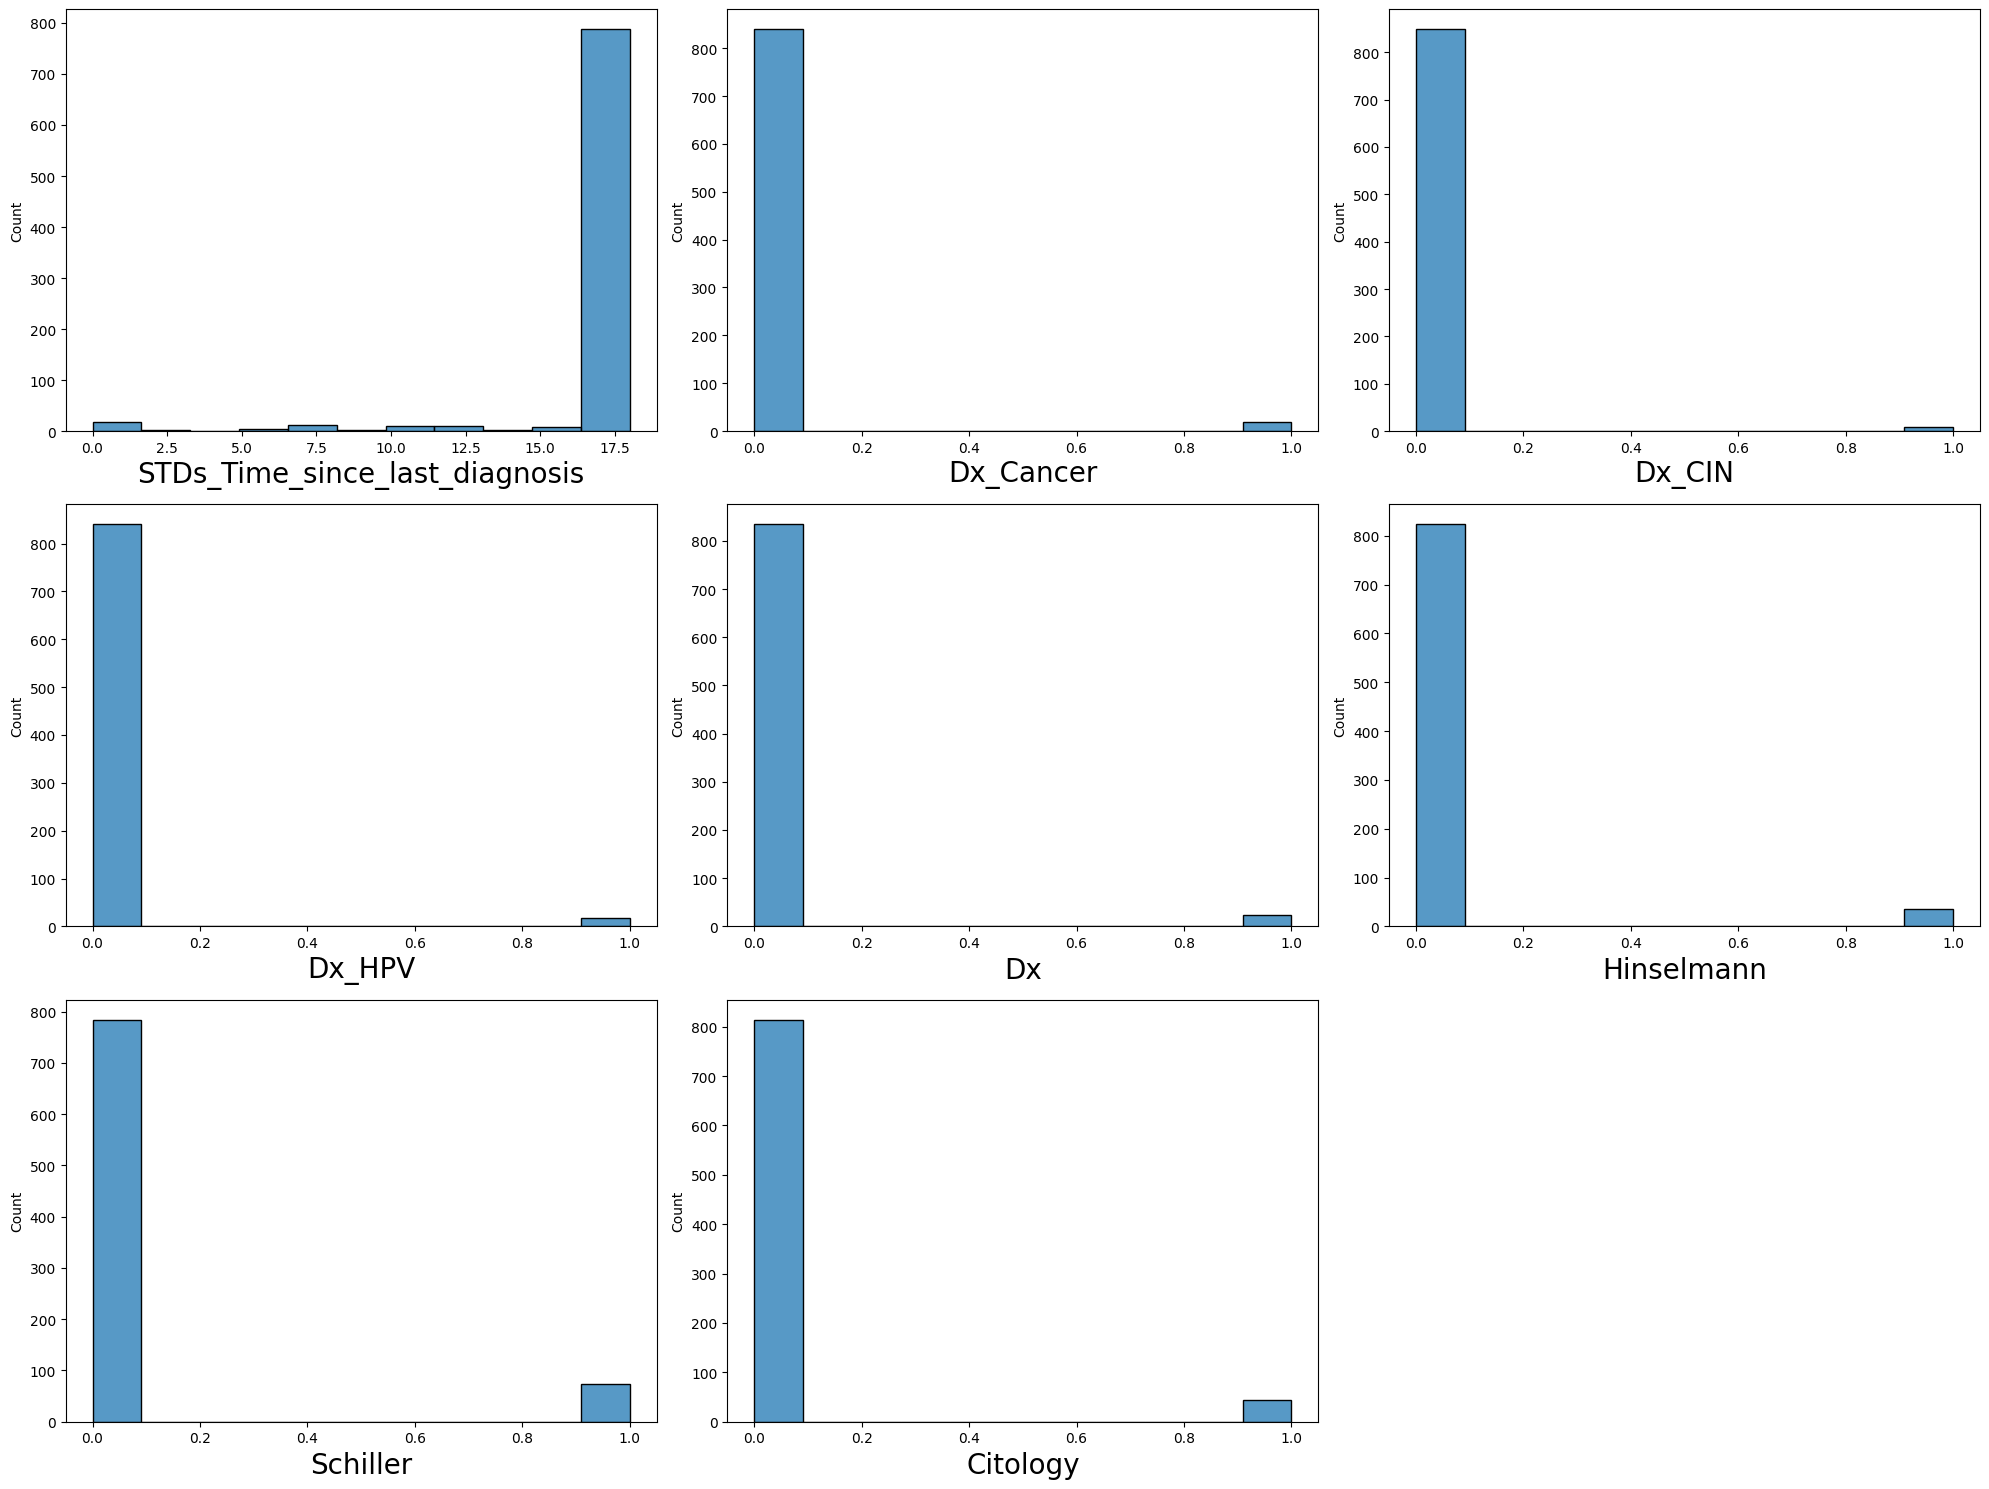

In [ ]:
cols1 = Cervical_Cancer_Data[['Age',
    'Number_of_sexual_partners',
    'First_sexual_intercourse',
    'Num_of_pregnancies',
    'Smokes',
    'Smokes_years',
    'Smokes_packs_per_year',
    'Hormonal_Contraceptives',
    'Hormonal_Contraceptives_years']
]

cols2 = Cervical_Cancer_Data[['IUD',
    'IUD_years',
    'STDs',
    'STDs_number',
    'STDs_condylomatosis',
    'STDs_cervical_condylomatosis',
    'STDs_vaginal_condylomatosis',
    'STDs_vulvo_perineal_condylomatosis',
    'STDs_syphilis']
]

cols3 = Cervical_Cancer_Data[['STDs_pelvic_inflammatory_disease',
    'STDs_genital_herpes',
    'STDs_molluscum_contagiosum',
    'STDs_AIDS',
    'STDs_HIV',
    'STDs_Hepatitis_B',
    'STDs_HPV',
    'STDs_Number_of_diagnosis',
    'STDs_Time_since_first_diagnosis']
]

cols4 = Cervical_Cancer_Data[['STDs_Time_since_last_diagnosis',
    'Dx_Cancer',
    'Dx_CIN',
    'Dx_HPV',
    'Dx',
    'Hinselmann',
    'Schiller',
    'Citology']
]

def chart_function(col):
    plt.figure(figsize=(20,15))
    plot_number = 1
    for column in col:
        if plot_number <= 9:
            ax = plt.subplot(3,3,plot_number)
            sns.histplot(col[column])
            plt.xlabel(column, fontsize=20)
        plot_number+=1
    plt.tight_layout()



chart_function(cols1)
chart_function(cols2)
chart_function(cols3)
chart_function(cols4)

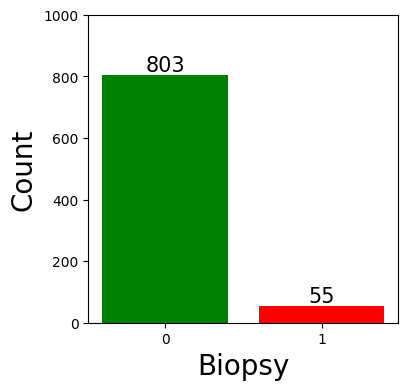

In [ ]:
plt.figure(figsize=(4,4))
names = ["0", "1"]
count = [(Cervical_Cancer_Data.Biopsy.values == 0).sum(), (Cervical_Cancer_Data.Biopsy.values == 1).sum()]
plt.bar(names, count, color = ["Green", "Red"])
plt.xlabel('Biopsy', fontsize= 20)
plt.ylabel('Count', fontsize= 20)
plt.ylim(0,1000)
for i in range(len(names)):
    plt.text(i, count[i], count[i], ha='center', va='bottom', fontsize=15)
plt.show()

In [ ]:
#Cervical_Cancer_Data.corr()

Cervical_Cancer_Data = Cervical_Cancer_Data.drop(['STDs_cervical_condylomatosis'], axis = 1)
Cervical_Cancer_Data = Cervical_Cancer_Data.drop(['STDs_AIDS'], axis = 1)

Cervical_Cancer_Data.corr()

## Heatmap for Dataset

<Axes: >

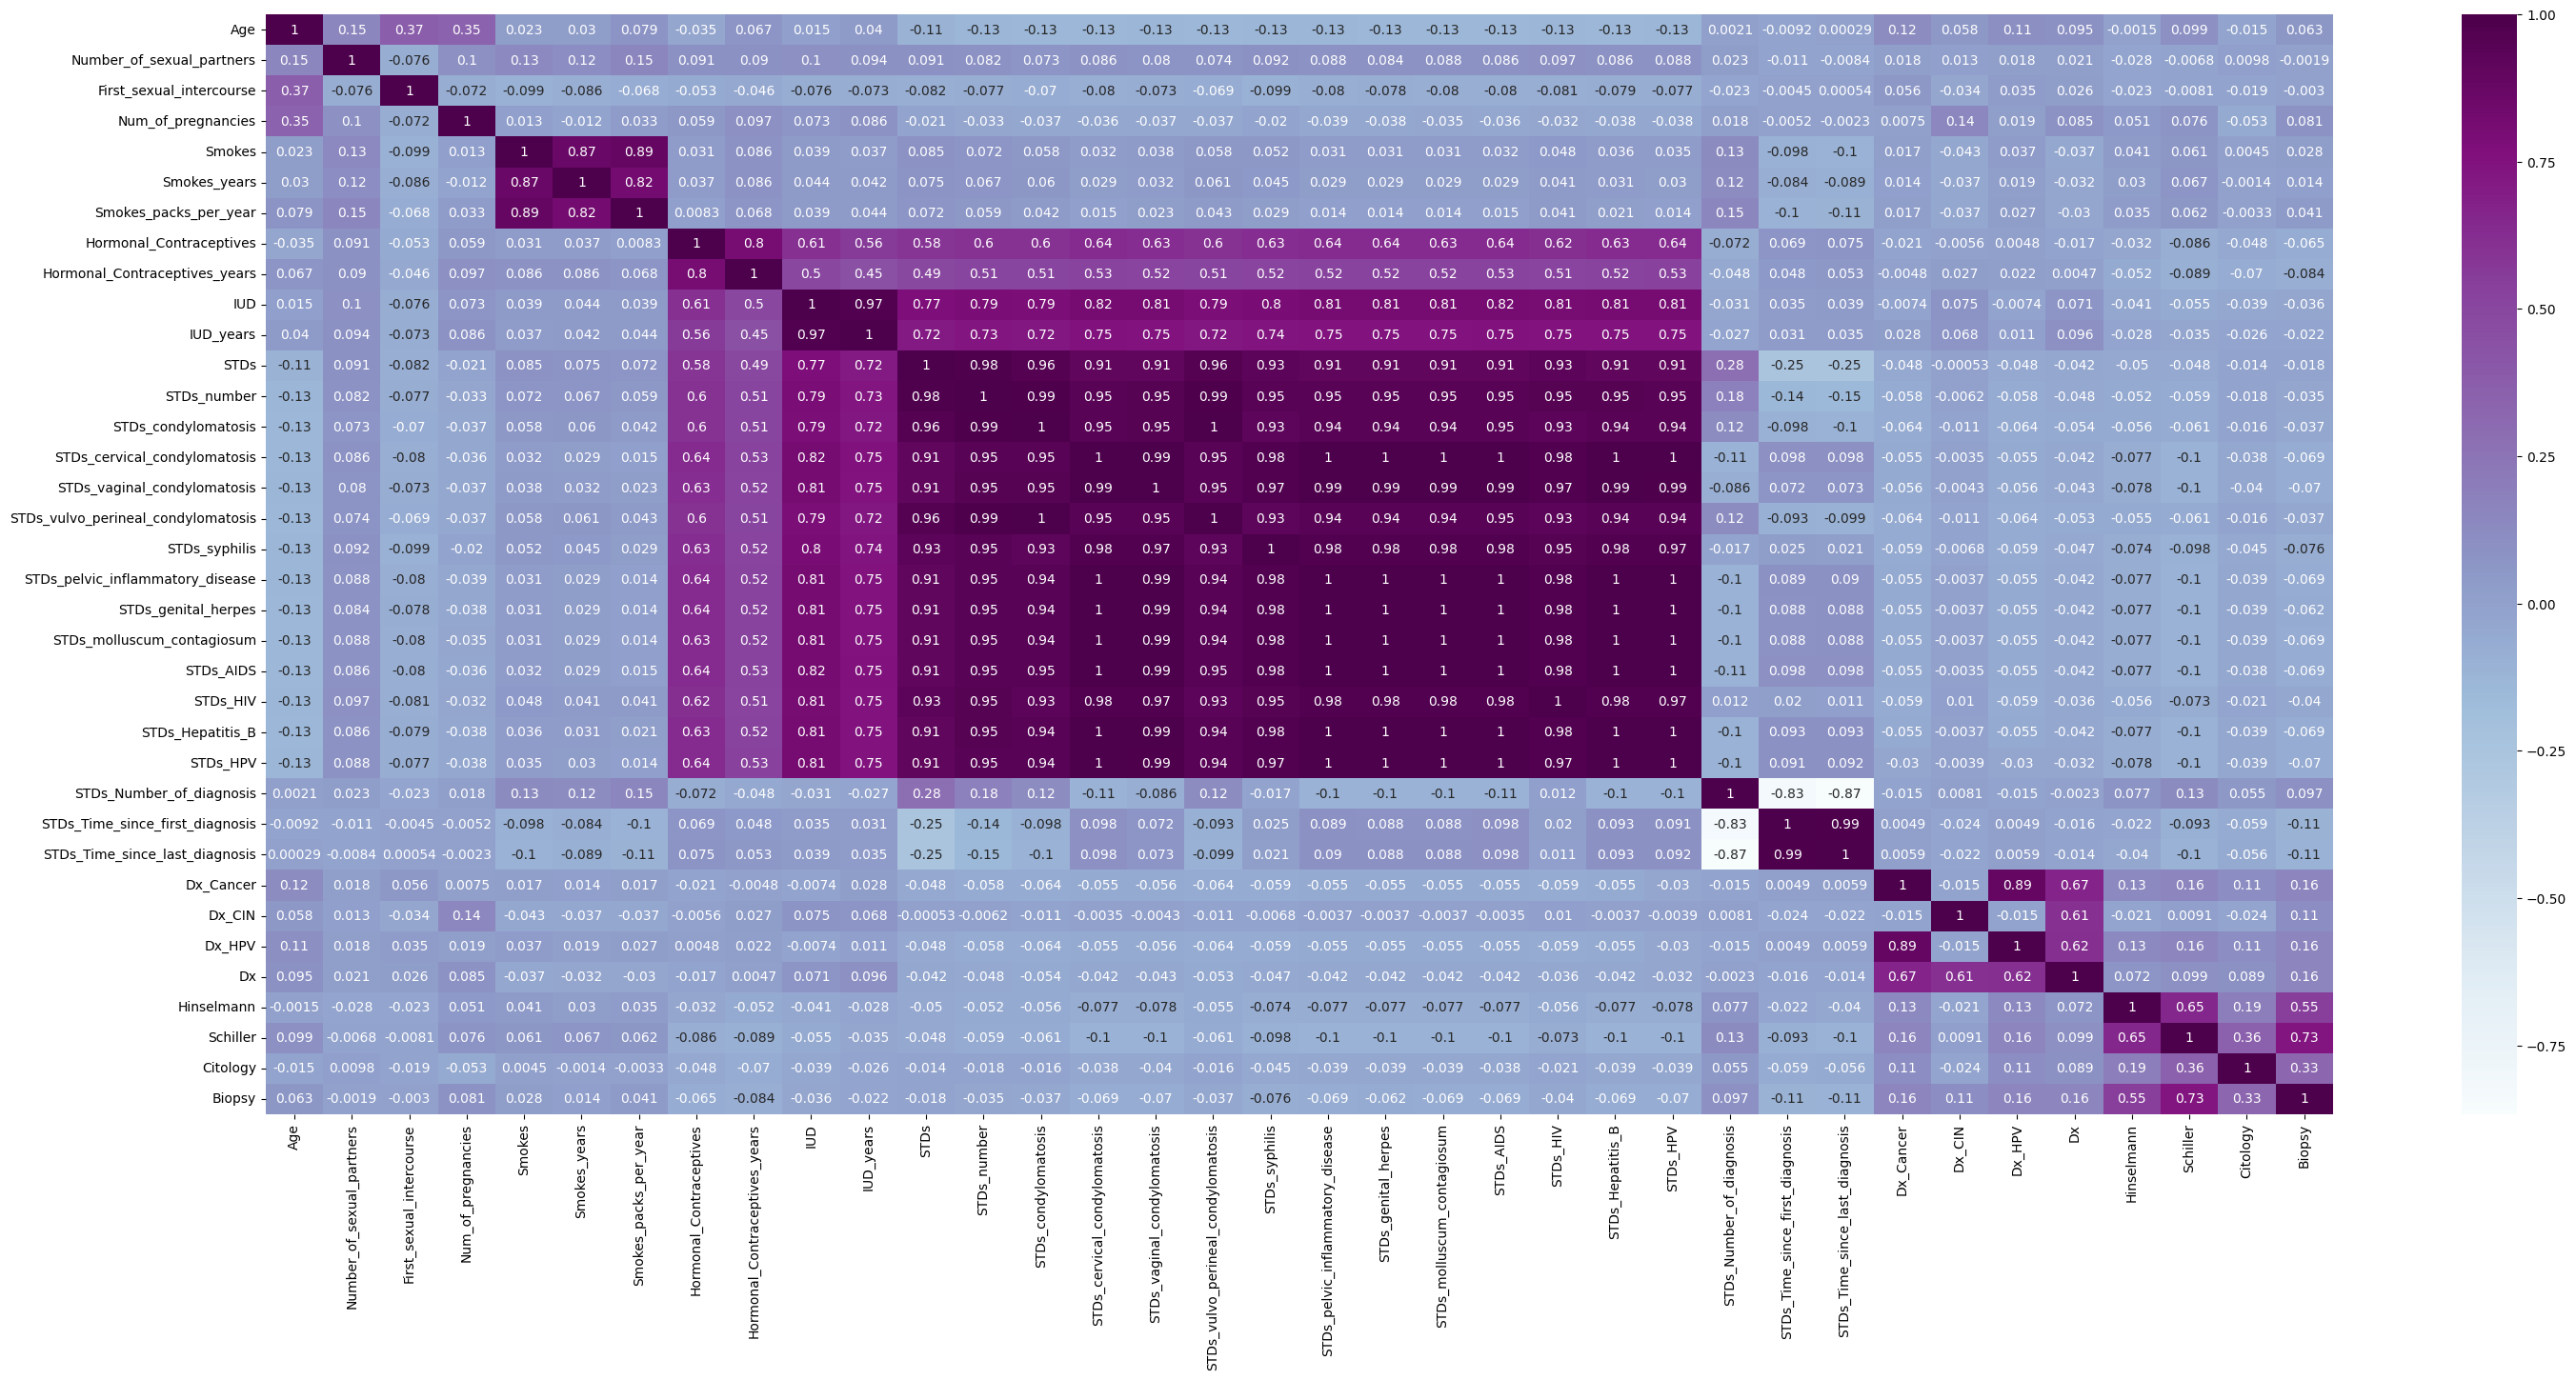

In [ ]:
plt.figure(figsize = (35,15))
sns.heatmap(Cervical_Cancer_Data.corr(), annot = True, cmap="BuPu")

## Scale & PCA

Scaler = StandardScaler()
Scaler.fit(X)
Scaled_x = Scaler.transform(X)
print(Scaled_x)


Pca = PCA(n_components = 4)
Pca.fit(Scaled_x)
x = Pca.transform(Scaled_x)
x.shape

## Train and test split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.35)#random_state=20

## SMOTE

sm = SMOTE()

x_train, y_train = sm.fit_resample(X_train, Y_train)
x_test, y_test = sm.fit_resample(X_test, Y_test)

## Machine Learning Model without optimization

In [ ]:
# Support Vector Machine (SVM)
svm = SVC().fit(x_train, y_train)

# Random Forest (RF)
RF = RandomForestClassifier().fit(x_train, y_train)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier().fit(x_train, y_train)

# Decision Tree (DT)
DT = DecisionTreeClassifier().fit(x_train, y_train)

# Naive Bayes (NB)
NB = GaussianNB().fit(x_train, y_train)

# Logistic Regression (LR)
LR = LogisticRegression(solver='liblinear',max_iter=3000).fit(x_train, y_train)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier().fit(x_train, y_train)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier().fit(x_train, y_train)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier().fit(x_train, y_train)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid().fit(x_train, y_train)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
VC = VotingClassifier(estimators = est, voting ='hard').fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Support Vector Machine (SVM)
svm_pre = svm.predict(x_test)
svm_sc = svm.score(x_test, y_test) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
rf_pre = RF.predict(x_test)
RF_sc = RF.score(x_test, y_test) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
knn_pre = KNN.predict(x_test)
KNN_sc = KNN.score(x_test, y_test) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
dt_pre = DT.predict(x_test)
DT_sc = DT.score(x_test, y_test) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
nb_pre = NB.predict(x_test)
NB_sc = NB.score(x_test, y_test) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
lr_pre = LR.predict(x_test)
LR_sc = LR.score(x_test, y_test) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
ab_pre = AB.predict(x_test)
AB_sc = AB.score(x_test, y_test) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
gb_pre = GB.predict(x_test)
GB_sc = GB.score(x_test, y_test) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
mlp_pre = MLP.predict(x_test)
MLP_sc = MLP.score(x_test, y_test) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
ncc_pre = NCC.predict(x_test)
NCC_sc = NCC.score(x_test, y_test) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
vc_pre = VC.predict(x_test)
vc_sc = VC.score(x_test, y_test) * 100
vc_sc = "{:.2f}".format(vc_sc)

## Figure for Accuracy

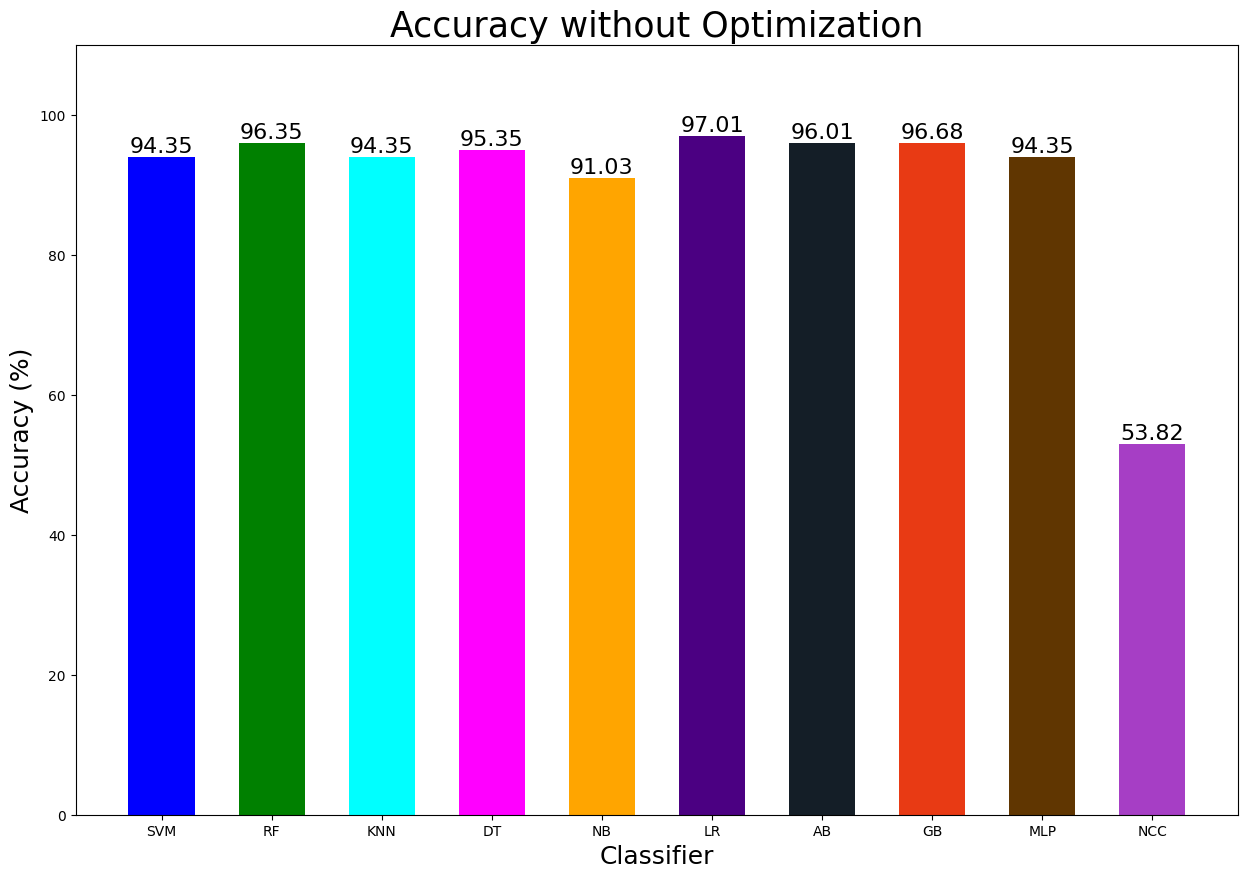

In [ ]:
plt.figure(figsize=(15,10))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5']
plt.bar(algo, acc, color=colors, width=0.6)
plt.title('Accuracy without Optimization', color = 'black', fontsize= 25)
plt.xlabel('Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

## Optimization

In [ ]:
os = RandomOverSampler(sampling_strategy=1)
x_os, y_os = os.fit_resample(x,y)
#print("Before fit {}".format(Counter(y)))
#print("After fit {}".format(Counter(y_os)))

# CV

In [ ]:
C = 15

## Machine Learning Model with optimization

In [ ]:
#Support Vector Machine (SVM)
svm = SVC(C= 1000, gamma= 0.0001, kernel= 'rbf')
svm_y_pre = cross_val_predict(svm, x_os, y_os, cv=C)
svm_sc = accuracy_score(y_os, svm_y_pre) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
RF = RandomForestClassifier()
rf_y_pre = cross_val_predict(RF, x_os, y_os, cv=C)
RF_sc = accuracy_score(y_os, rf_y_pre) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors= 1, weights= 'uniform')
knn_y_pre = cross_val_predict(KNN, x_os, y_os, cv=C)
KNN_sc = accuracy_score(y_os, knn_y_pre) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
DT = DecisionTreeClassifier(criterion= 'gini', max_depth= 20, min_samples_leaf= 5)
dt_y_pre = cross_val_predict(DT, x_os, y_os, cv=C)
DT_sc = accuracy_score(y_os, dt_y_pre) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
NB = GaussianNB()
nb_y_pre = cross_val_predict(NB, x_os, y_os, cv=5)
NB_sc = accuracy_score(y_os, nb_y_pre) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
LR = LogisticRegression(max_iter=3000,C= 1.0, penalty= 'l2', solver= 'liblinear')
lr_y_pre = cross_val_predict(LR, x_os, y_os, cv=5)
LR_sc = accuracy_score(y_os, lr_y_pre) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier()
ab_y_pre = cross_val_predict(AB, x_os, y_os, cv=C)
AB_sc = accuracy_score(y_os, ab_y_pre) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier()
gb_y_pre = cross_val_predict(GB, x_os, y_os, cv=C)
GB_sc = accuracy_score(y_os, gb_y_pre) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier(max_iter=3000)
mlp_y_pre = cross_val_predict(MLP, x_os, y_os, cv=C)
MLP_sc = accuracy_score(y_os, mlp_y_pre) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid()
ncc_y_pre = cross_val_predict(NCC, x_os, y_os, cv=C)
NCC_sc = accuracy_score(y_os, ncc_y_pre) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

## Figure for Accuracy

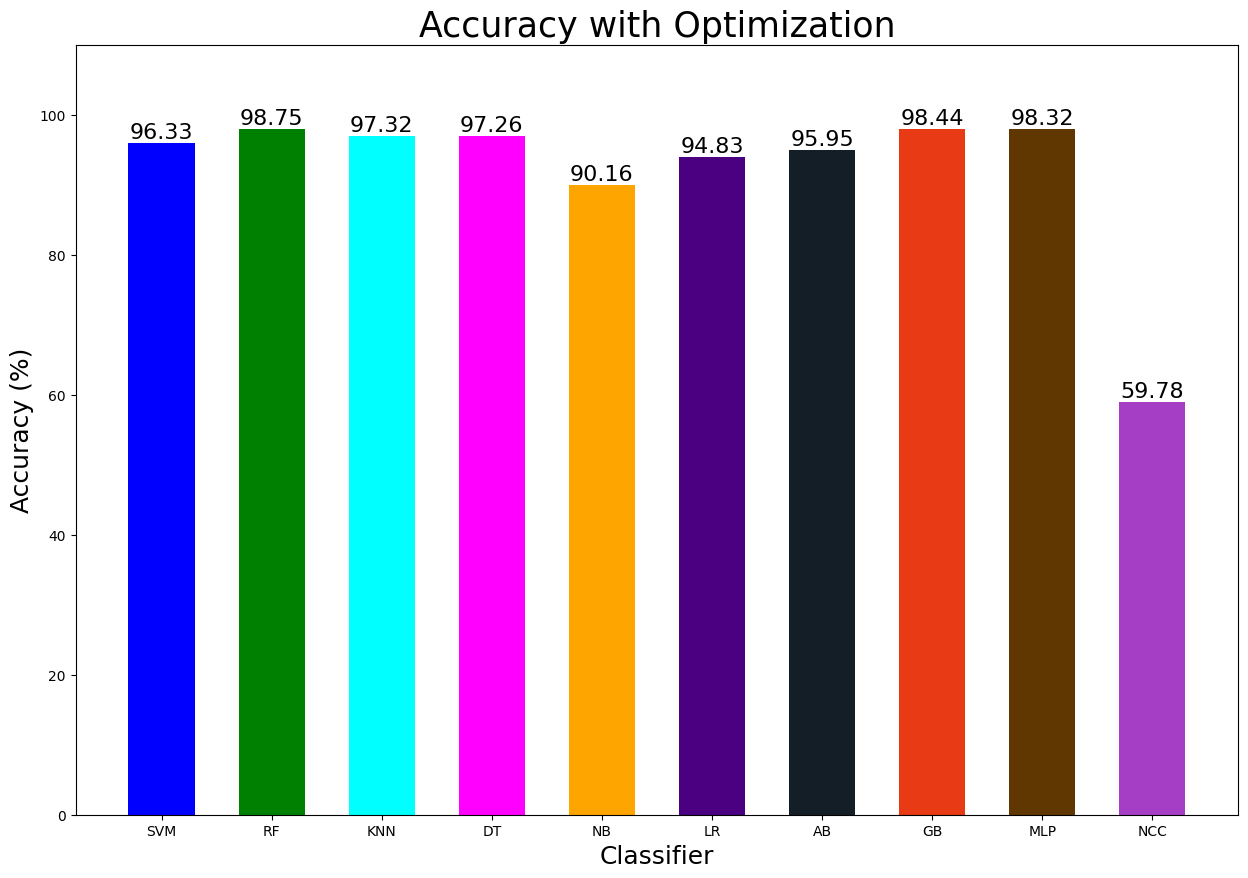

In [ ]:
plt.figure(figsize=(15,10))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5']
plt.bar(algo, acc, color=colors, width=0.6)
plt.title('Accuracy with Optimization', color = 'black', fontsize= 25)
plt.xlabel('Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

## Voting Classifier

In [ ]:
def VotingClassifierMethod(est, Type):
    vot = VotingClassifier(estimators = est, voting = Type)
    vc_y_pre = cross_val_predict(vot, x_os, y_os, cv=C)
    vc_sc = accuracy_score(y_os, vc_y_pre) * 100
    vc_sc = "{:.2f}".format(vc_sc)
    return vc_sc


est1 = [('gb',GB), ('rf',RF)]
est2 = [('gb',GB), ('mlp',MLP)]
est3 = [('rf',RF), ('mlp',MLP)]
est4 = [('gb',GB), ('rf',RF), ('mlp',MLP)]

a1 = VotingClassifierMethod(est1, 'hard')
b1 = VotingClassifierMethod(est1, 'soft')

a2 = VotingClassifierMethod(est2, 'hard')
b2 = VotingClassifierMethod(est2, 'soft')

a3 = VotingClassifierMethod(est3, 'hard')
b3 = VotingClassifierMethod(est3, 'soft')

a4 = VotingClassifierMethod(est4, 'hard')
b4 = VotingClassifierMethod(est4, 'soft')

print("Max = {}".format(max(a1, b1, a2, b2, a3, b3, a4, b4)))

Max = 99.19


### Figure for Accuracy (Voting)

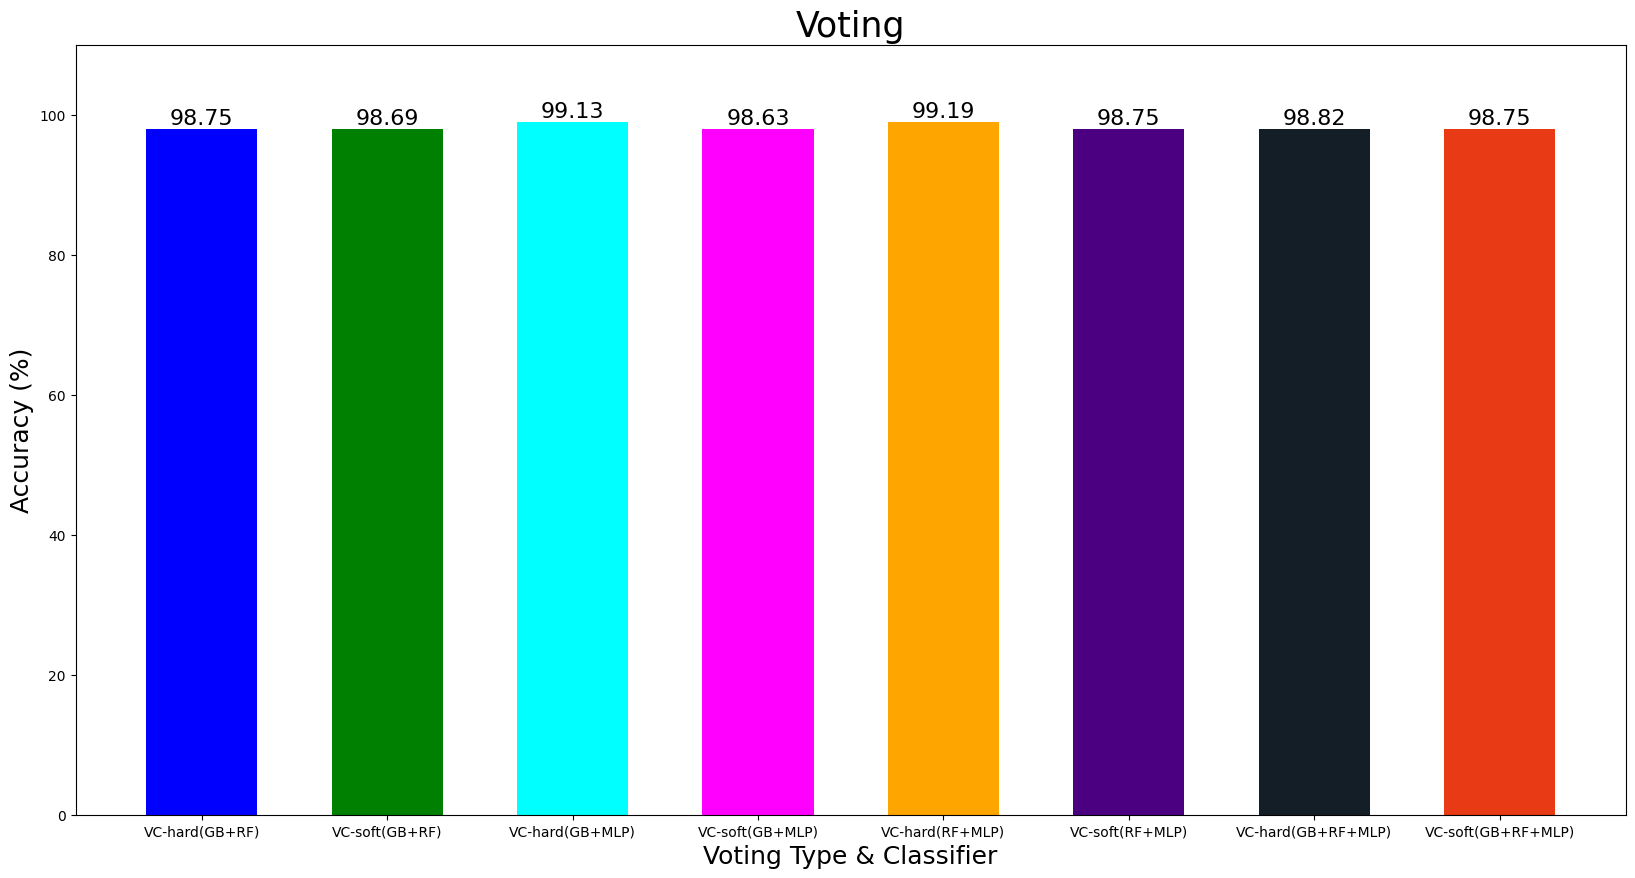

In [ ]:
plt.figure(figsize=(20,10))
algo = ['VC-hard(GB+RF)', 'VC-soft(GB+RF)', 'VC-hard(GB+MLP)', 'VC-soft(GB+MLP)', 'VC-hard(RF+MLP)', 'VC-soft(RF+MLP)', 'VC-hard(GB+RF+MLP)', 'VC-soft(GB+RF+MLP)']
acc = [math.floor(int(float(a1))),math.floor(int(float(b1))),math.floor(int(float(a2))),math.floor(int(float(b2))),math.floor(int(float(a3))),math.floor(int(float(b3))),math.floor(int(float(a4))),math.floor(int(float(b4)))]
pert = [a1, b1, a2, b2, a3, b3, a4, b4]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14']
plt.bar(algo, acc,color=colors,width=0.6)
plt.title('Voting', color = 'black', fontsize= 25)
plt.xlabel('Voting Type & Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

## Confusion Matrix & Classification Report

In [ ]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (7,4), fontsize=14, title = "Confusion Matrix"):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap='cividis')
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=90, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=0, ha='center', fontsize=fontsize)
    plt.ylabel('Actual', fontsize=18, color='blue')
    plt.xlabel('Prediction',  fontsize=18, color='blue')
    plt.title(title, fontsize=22, color='blue')

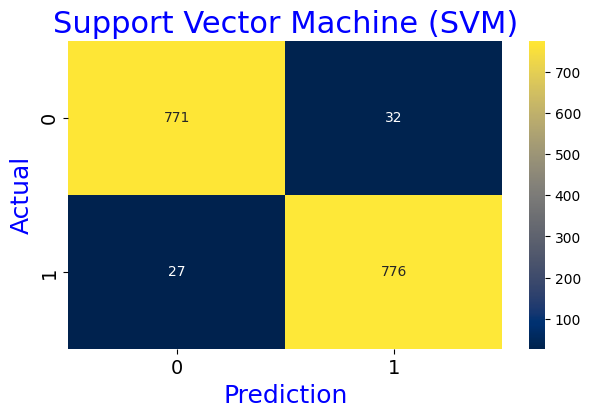

In [ ]:
cm = confusion_matrix(y_os, svm_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Support Vector Machine (SVM)")

In [ ]:
pd.DataFrame(classification_report(y_os, svm_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.966165,0.960396,0.963263,0.963281,0.963281
recall,0.960149,0.966376,0.963263,0.963263,0.963263
f1-score,0.963148,0.963377,0.963263,0.963262,0.963262
support,803.000000,803.000000,0.963263,1606.000000,1606.000000


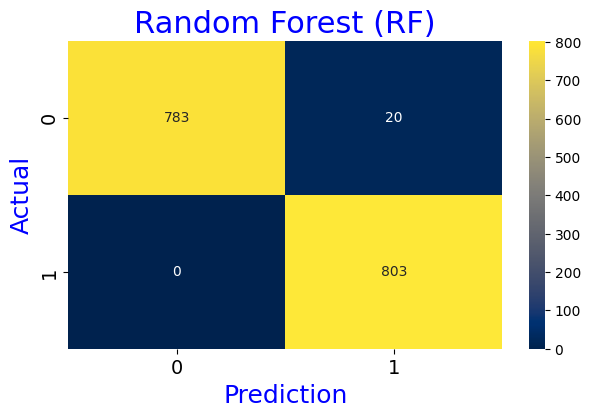

In [ ]:
cm = confusion_matrix(y_os, rf_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Random Forest (RF)")

In [ ]:
pd.DataFrame(classification_report(y_os, rf_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.975699,0.987547,0.987849,0.987849
recall,0.975093,1.000000,0.987547,0.987547,0.987547
f1-score,0.987390,0.987700,0.987547,0.987545,0.987545
support,803.000000,803.000000,0.987547,1606.000000,1606.000000


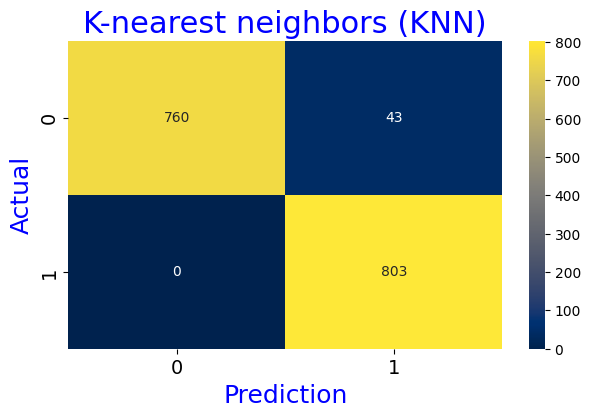

In [ ]:
cm = confusion_matrix(y_os, knn_y_pre)
print_confusion_matrix(cm,["0", "1"], title="K-nearest neighbors (KNN)")

In [ ]:
pd.DataFrame(classification_report(y_os, knn_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.949173,0.973225,0.974586,0.974586
recall,0.946451,1.000000,0.973225,0.973225,0.973225
f1-score,0.972489,0.973924,0.973225,0.973206,0.973206
support,803.000000,803.000000,0.973225,1606.000000,1606.000000


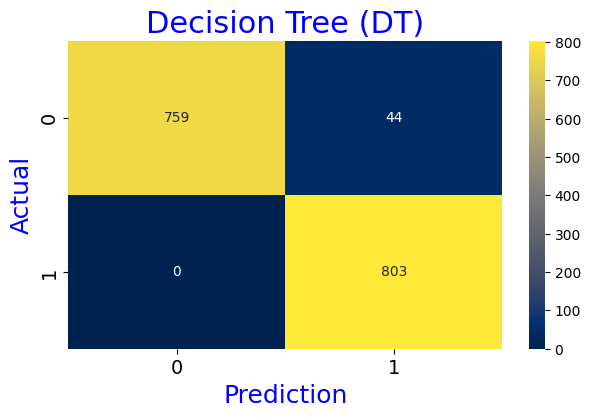

In [ ]:
cm = confusion_matrix(y_os, dt_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Decision Tree (DT)")

In [ ]:
pd.DataFrame(classification_report(y_os, dt_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.948052,0.972603,0.974026,0.974026
recall,0.945205,1.000000,0.972603,0.972603,0.972603
f1-score,0.971831,0.973333,0.972603,0.972582,0.972582
support,803.000000,803.000000,0.972603,1606.000000,1606.000000


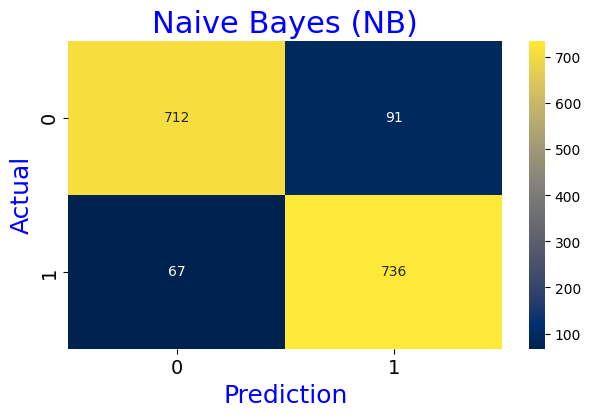

In [ ]:
cm = confusion_matrix(y_os, nb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Naive Bayes (NB)")

In [ ]:
pd.DataFrame(classification_report(y_os, nb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.913992,0.889964,0.901619,0.901978,0.901978
recall,0.886675,0.916563,0.901619,0.901619,0.901619
f1-score,0.900126,0.903067,0.901619,0.901597,0.901597
support,803.000000,803.000000,0.901619,1606.000000,1606.000000


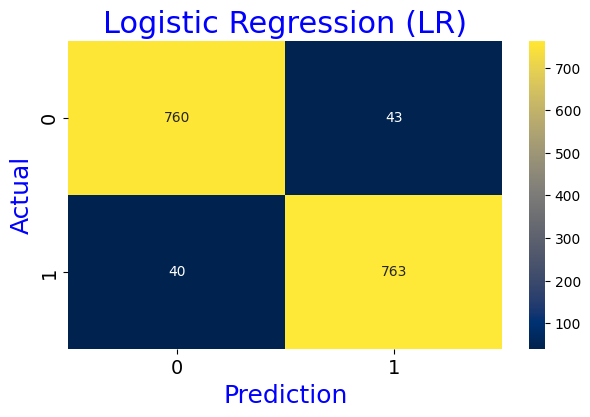

In [ ]:
cm = confusion_matrix(y_os, lr_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Logistic Regression (LR)")

In [ ]:
pd.DataFrame(classification_report(y_os, lr_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.950000,0.946650,0.948319,0.948325,0.948325
recall,0.946451,0.950187,0.948319,0.948319,0.948319
f1-score,0.948222,0.948415,0.948319,0.948319,0.948319
support,803.000000,803.000000,0.948319,1606.000000,1606.000000


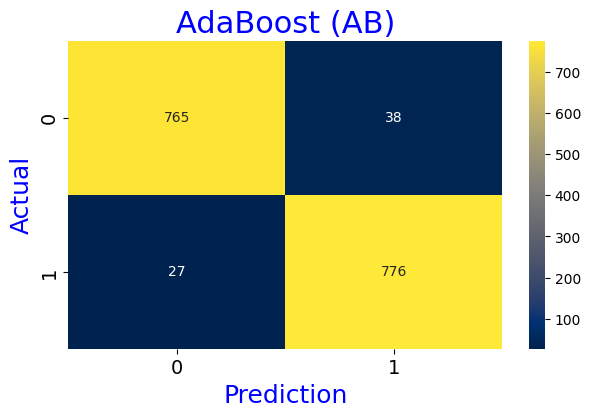

In [ ]:
cm = confusion_matrix(y_os, ab_y_pre)
print_confusion_matrix(cm,["0", "1"], title="AdaBoost (AB)")

In [ ]:
pd.DataFrame(classification_report(y_os, ab_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.965909,0.953317,0.959527,0.959613,0.959613
recall,0.952677,0.966376,0.959527,0.959527,0.959527
f1-score,0.959248,0.959802,0.959527,0.959525,0.959525
support,803.000000,803.000000,0.959527,1606.000000,1606.000000


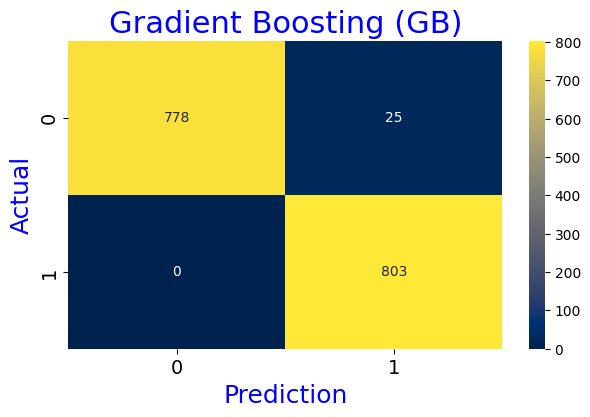

In [ ]:
cm = confusion_matrix(y_os, gb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Gradient Boosting (GB)")

In [ ]:
pd.DataFrame(classification_report(y_os, gb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.969807,0.984433,0.984903,0.984903
recall,0.968867,1.000000,0.984433,0.984433,0.984433
f1-score,0.984187,0.984672,0.984433,0.984430,0.984430
support,803.000000,803.000000,0.984433,1606.000000,1606.000000


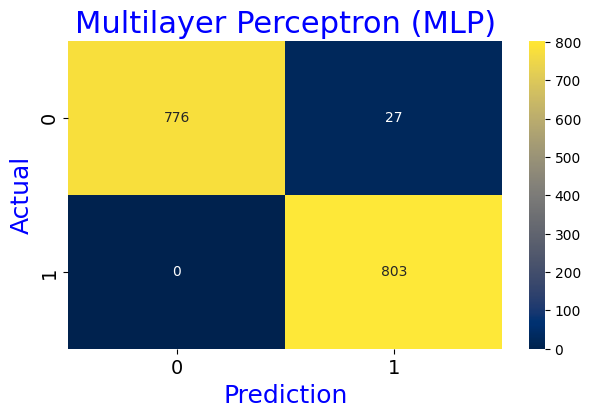

In [ ]:
cm = confusion_matrix(y_os, mlp_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Multilayer Perceptron (MLP)")

In [ ]:
pd.DataFrame(classification_report(y_os, mlp_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.967470,0.983188,0.983735,0.983735
recall,0.966376,1.000000,0.983188,0.983188,0.983188
f1-score,0.982901,0.983466,0.983188,0.983183,0.983183
support,803.000000,803.000000,0.983188,1606.000000,1606.000000


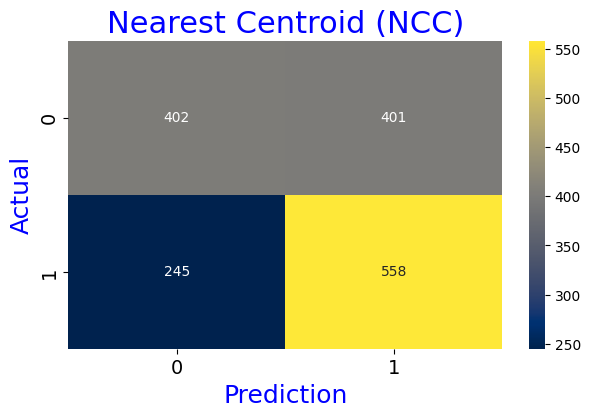

In [ ]:
cm = confusion_matrix(y_os, ncc_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Nearest Centroid (NCC)")

In [ ]:
pd.DataFrame(classification_report(y_os, ncc_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.621329,0.581856,0.597758,0.601593,0.601593
recall,0.500623,0.694894,0.597758,0.597758,0.597758
f1-score,0.554483,0.633371,0.597758,0.593927,0.593927
support,803.000000,803.000000,0.597758,1606.000000,1606.000000


cm = confusion_matrix(y_os, vc_y_pre_hard)
print_confusion_matrix(cm,["0", "1"], title="Voting Classifier (VC)")

pd.DataFrame(classification_report(y_os, vc_y_pre_hard, output_dict=True))

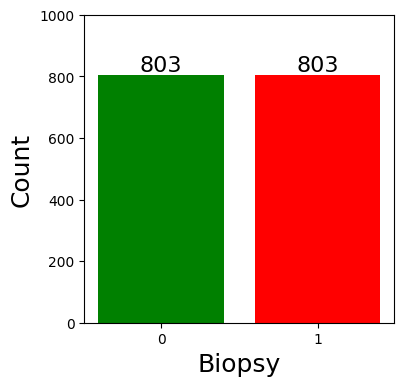

In [ ]:
plt.figure(figsize=(4,4))
names = ["0", "1"]
count = [(y_os.values == 0).sum(), (y_os.values == 1).sum()]
plt.bar(names, count, color = ["Green", "Red"])
plt.xlabel('Biopsy', fontsize= 18)
plt.ylabel('Count', fontsize= 18)
plt.ylim(0,1000)
for i in range(len(names)):
    plt.text(i, count[i], count[i], ha='center', va='bottom', fontsize=16)
plt.show()